In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv("../data/processed/credit_risk_feature_engineered.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,TOTAL_PAYMENT,AVG_PAYMENT,CREDIT_UTILIZATION,PAYMENT_RATIO,AVG_DELAY,MAX_DELAY,NUM_DELAY_MONTHS,RECENT_DELAY_FLAG,BILL_GROWTH,PAYMENT_STD
0,1,20000,2,2,1,24,2,2,-1,-1,...,689,114.833333,0.385181,0.089422,-0.333333,2,2,1,3913,281.283072
1,2,120000,2,2,2,26,-1,2,0,0,...,5000,833.333333,0.142307,0.292774,0.500000,2,2,0,-579,752.772653
2,3,90000,2,2,2,34,0,0,0,0,...,11018,1836.333333,1.129465,0.108387,0.000000,0,0,0,13690,1569.815488
3,4,50000,2,2,1,37,0,0,0,0,...,8388,1398.000000,4.626587,0.036259,0.000000,0,0,0,17443,478.058155
4,5,50000,1,2,1,57,-1,0,-1,0,...,59049,9841.500000,2.186736,0.540049,-0.333333,0,0,0,-10514,13786.230736


In [3]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month', 'AGE_GROUP', 'TOTAL_BILL', 'AVG_BILL', 'TOTAL_PAYMENT', 'AVG_PAYMENT', 'CREDIT_UTILIZATION', 'PAYMENT_RATIO', 'AVG_DELAY', 'MAX_DELAY', 'NUM_DELAY_MONTHS', 'RECENT_DELAY_FLAG', 'BILL_GROWTH', 'PAYMENT_STD']


In [4]:
target = "default payment next month"

feature_columns = [
    col
    for col in df.columns
    if col not in [
        target,
        "ID", "SEX", "MARRIAGE", "AGE", "TOTAL_BILL", "AVG_BILL", "TOTAL_PAYMENT", "AVG_PAYMENT", "AVG_DELAY"
    ]
]

print("Number of Features:", len(feature_columns))
print(feature_columns)

Number of Features: 28
['LIMIT_BAL', 'EDUCATION', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP', 'CREDIT_UTILIZATION', 'PAYMENT_RATIO', 'MAX_DELAY', 'NUM_DELAY_MONTHS', 'RECENT_DELAY_FLAG', 'BILL_GROWTH', 'PAYMENT_STD']


In [5]:
X = df[feature_columns]
y = df[target]
print(X.shape)
print(y.shape)

(30000, 28)
(30000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (24000, 28)
Test Shape: (6000, 28)


In [7]:
# Baseline model

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

c:\Users\priti\anaconda3\envs\credit_risk_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [8]:
#Baseline model performance

y_pred_lr = lr_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_lr))

Accuracy : 0.7383333333333333
Precision: 0.4317798989331836
Recall   : 0.5795026375282593
F1 Score : 0.4948519948519948
ROC AUC  : 0.6814697009597213


In [9]:
rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_balanced.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_balanced))
print("Precision:", precision_score(y_test, y_pred_rf_balanced))
print("Recall   :", recall_score(y_test, y_pred_rf_balanced))
print("F1 Score :", f1_score(y_test, y_pred_rf_balanced))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rf_balanced))

Accuracy : 0.7818333333333334
Precision: 0.5057989690721649
Recall   : 0.5915599095704597
F1 Score : 0.5453282389718652
ROC AUC  : 0.7137127602635093


In [11]:
cm = confusion_matrix(y_test,y_pred_rf_balanced)
print(cm)

[[3906  767]
 [ 542  785]]


In [12]:
y_prob_rf = rf_model_balanced.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

In [13]:
thresholds

array([       inf, 0.9806596 , 0.97986939, ..., 0.10086182, 0.10040116,
       0.07499958], shape=(1657,))

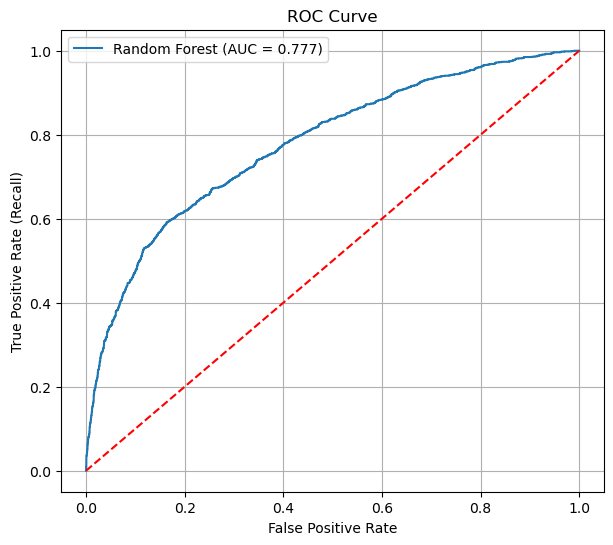

In [14]:
# Predicted probabilities for the positive class
y_prob_rf = rf_model_balanced.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

# Plot ROC Curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_pred = (y_prob_rf >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(results)

threshold_df.sort_values(
    by="Recall",
    ascending=False
).head(15)

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.229167,0.222950,1.000000,0.364611
1,0.11,0.234333,0.223931,0.998493,0.365820
2,0.12,0.248000,0.226984,0.997739,0.369832
3,0.13,0.262000,0.229925,0.994725,0.373514
4,0.14,0.276167,0.232908,0.990957,0.377169
5,0.15,0.290333,0.235803,0.985682,0.380564
6,0.16,0.306167,0.239530,0.982668,0.385172
7,0.17,0.324000,0.243370,0.975132,0.389524
8,0.18,0.342000,0.248029,0.972118,0.395221
9,0.19,0.363000,0.253410,0.966089,0.401503


In [16]:
filtered = threshold_df[threshold_df["Precision"] >= 0.40]

best_row = filtered.loc[
    filtered["Recall"].idxmax()
]

best_threshold = best_row["Threshold"]
print("Best Threshold:", best_threshold)
print(best_row)

Best Threshold: 0.3999999999999998
Threshold    0.400000
Accuracy     0.709500
Precision    0.406559
Recall       0.681989
F1           0.509429
Name: 30, dtype: float64


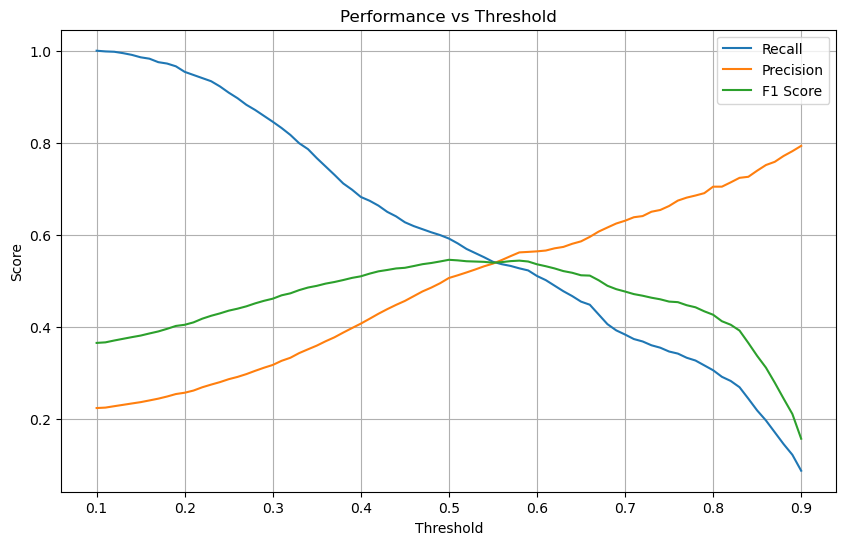

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Performance vs Threshold")
plt.grid(True)
plt.legend()

plt.show()

In [18]:
y_pred_new = (y_prob_rf >= best_threshold).astype(int)
#now we will predict using the best threshold to get high recall but still manageable precision and f1

In [20]:
print("Threshold:", best_threshold)

print("Accuracy :", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall   :", recall_score(y_test, y_pred_new))
print("F1 Score :", f1_score(y_test, y_pred_new))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_new))

Threshold: 0.3999999999999998
Accuracy : 0.7095
Precision: 0.40655884995507635
Recall   : 0.6819894498869631
F1 Score : 0.5094286518435125
ROC AUC  : 0.7770622203809632

Confusion Matrix
[[3352 1321]
 [ 422  905]]


In [21]:
# scale_pos_weight tells XGBoost how much more to penalise
# missing a positive (default) vs a negative.
# Ratio = count(0) / count(1) in the training labels.

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

print(f"Negatives : {neg}")
print(f"Positives : {pos}")
print(f"scale_pos_weight : {spw:.4f}")

Negatives : 18691
Positives : 5309
scale_pos_weight : 3.5206


In [22]:
xgb_base = XGBClassifier(
    scale_pos_weight=spw,   # handles class imbalance natively
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"      # faster tree method
)

In [23]:
param_dist = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [3, 4, 5, 6, 7],
    "learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "subsample"        : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight" : [1, 3, 5, 7],
    "gamma"            : [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha"        : [0, 0.01, 0.1, 1.0],    # L1 regularisation
    "reg_lambda"       : [0.1, 0.5, 1.0, 2.0],   # L2 regularisation
}

In [24]:
# roc_auc is the best scoring metric for imbalanced problems
# because it evaluates rank-ordering across all thresholds.

rscv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=60,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rscv.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\priti\anaconda3\envs\credit_risk_ml\lib\site-packages\xgboost\training.py:200: UserWarning: [00:06:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,60
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
print("Best CV ROC-AUC :", round(rscv.best_score_, 4))
print("\nBest Parameters:")
for k, v in rscv.best_params_.items():
    print(f"  {k}: {v}")

Best CV ROC-AUC : 0.7887

Best Parameters:
  subsample: 0.6
  reg_lambda: 1.0
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.7


In [26]:
xgb_model = rscv.best_estimator_

In [27]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

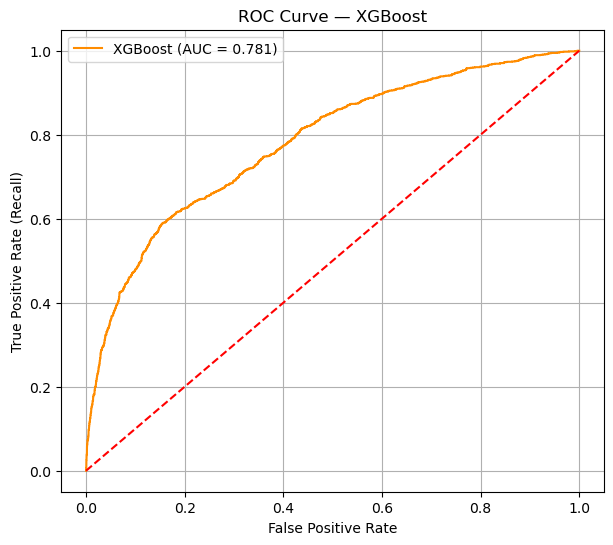

In [28]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
xgb_results = []

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred = (y_prob_xgb >= threshold).astype(int)

    xgb_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred),
        "F1"       : f1_score(y_test, y_pred)
    })

xgb_threshold_df = pd.DataFrame(xgb_results)

xgb_threshold_df.sort_values("Recall", ascending=False).head(15)

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.231833,0.223365,0.998493,0.365064
1,0.11,0.241833,0.225554,0.997739,0.367931
2,0.12,0.252500,0.227759,0.995479,0.370703
3,0.13,0.265833,0.230756,0.993971,0.374556
4,0.14,0.280167,0.233713,0.989450,0.378114
5,0.15,0.295000,0.236999,0.985682,0.382121
6,0.16,0.307167,0.239411,0.979653,0.384786
7,0.17,0.322500,0.242766,0.973625,0.388630
8,0.18,0.338167,0.246743,0.970610,0.393463
9,0.19,0.352667,0.250439,0.966843,0.397829


In [36]:
xgb_filtered = xgb_threshold_df[xgb_threshold_df["Precision"] >= 0.37]

xgb_best_row = xgb_filtered.loc[xgb_filtered["Recall"].idxmax()]

xgb_best_threshold = xgb_best_row["Threshold"]
print("Best Threshold:", xgb_best_threshold)
print(xgb_best_row)

Best Threshold: 0.4
Threshold    0.400000
Accuracy     0.668333
Precision    0.373618
Recall       0.738508
F1           0.496203
Name: 30, dtype: float64


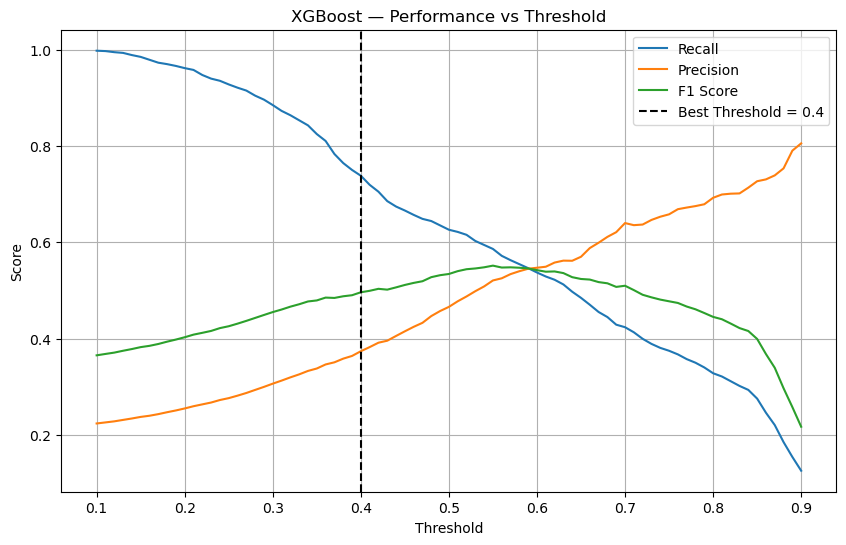

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(xgb_threshold_df["Threshold"], xgb_threshold_df["Recall"],    label="Recall")
plt.plot(xgb_threshold_df["Threshold"], xgb_threshold_df["Precision"], label="Precision")
plt.plot(xgb_threshold_df["Threshold"], xgb_threshold_df["F1"],        label="F1 Score")

plt.axvline(x=xgb_best_threshold, color="black", linestyle="--",
            label=f"Best Threshold = {xgb_best_threshold}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost — Performance vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
y_pred_xgb_new = (y_prob_xgb >= xgb_best_threshold).astype(int)

In [40]:
print("XGBoost (tuned threshold)")
print(f"Threshold : {xgb_best_threshold}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb_new):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb_new):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_new):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb_new):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb_new))

XGBoost (tuned threshold)
Threshold : 0.4
Accuracy  : 0.6683
Precision : 0.3736
Recall    : 0.7385
F1 Score  : 0.4962
ROC AUC   : 0.7810

Confusion Matrix
[[3030 1643]
 [ 347  980]]
